# Flare Distribution Model


In [27]:
# --- Standard Library ---
import os
import math
import time
from pathlib import Path

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import ScalarFormatter, FixedLocator, FuncFormatter, MaxNLocator
from tqdm import tqdm

# Reproducible random numbers
rng = np.random.default_rng(42)

# --- Global Settings ---
np.set_printoptions(suppress=True, precision=6)

# ------------------------------------------------------------
# Thesis-style plotting constants
# ------------------------------------------------------------
BASE_FONTSIZE = 20
BASE_LINEWIDTH = 2.2
SCALE = 1.8

FONTSIZE = BASE_FONTSIZE * SCALE
LINEWIDTH = BASE_LINEWIDTH * SCALE
PANEL_FONTSIZE = FONTSIZE * 1.05

PRIMARY_COLOR = "black"
RAW_COLOR = "grey"
MODEL_COLOR = "crimson"
SPAN_COLOR = "lightblue"

plt.rcParams.update({
    "font.size": FONTSIZE,
    "axes.labelsize": FONTSIZE,
    "xtick.labelsize": FONTSIZE,
    "ytick.labelsize": FONTSIZE,
    "axes.linewidth": LINEWIDTH,
    "mathtext.fontset": "stix",
    "figure.dpi": 150,
})

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plain_scalar_formatter():
    """Return a non-scientific scalar formatter without offset notation."""
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    return formatter


def apply_thesis_axis_style(ax, *, integer_y=False, scalar_x=True, scalar_y=True):
    """Apply the common thesis tick, spine, and scalar-format style to one axis."""
    ax.tick_params(
        axis="both",
        which="major",
        width=LINEWIDTH,
        length=7 * SCALE,
        pad=10,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        width=LINEWIDTH * 0.8,
        length=4 * SCALE,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(LINEWIDTH)

    if integer_y:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    if scalar_x and ax.get_xscale() == "linear":
        ax.xaxis.set_major_formatter(plain_scalar_formatter())
    if scalar_y and ax.get_yscale() == "linear":
        ax.yaxis.set_major_formatter(plain_scalar_formatter())


def add_panel_label(ax, label):
    """Add a thesis-style panel label in the upper-left corner."""
    ax.text(
        0.03,
        0.93,
        label,
        transform=ax.transAxes,
        fontsize=PANEL_FONTSIZE,
        fontweight="bold",
        ha="left",
        va="top",
        color="black",
        zorder=50,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=4),
    )


def add_inner_label(ax, text, *, loc="upper right"):
    """Add a small descriptive label inside an axis without using a title."""
    x, ha = (0.97, "right") if loc == "upper right" else (0.08, "left")
    ax.text(
        x,
        0.92,
        text,
        transform=ax.transAxes,
        fontsize=FONTSIZE * 0.82,
        ha=ha,
        va="top",
        color="black",
        zorder=45,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=3),
    )


def add_spi_region(ax, spi_width=0.25, *, label=None):
    """Mark the central SPI/observable phase window."""
    ax.axvspan(
        -spi_width,
        spi_width,
        color=SPAN_COLOR,
        alpha=0.35,
        linewidth=0,
        zorder=0,
        label=label,
    )
    ax.axvline(-spi_width, color=RAW_COLOR, lw=LINEWIDTH, ls=":", zorder=2)
    ax.axvline(spi_width, color=RAW_COLOR, lw=LINEWIDTH, ls=":", zorder=2)


def save_thesis_figure(fig, filename):
    """Save an individual PDF figure with thesis export settings."""
    path = FIGURES_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path


## Main functions

The model is made from two parts:

1. an intrinsic stellar component, which is uniform over orbital phase;
2. a planet-induced component, which is concentrated inside the SPI phase region.

The two components are mixed as

$p_{\rm total}(\phi) = (1-\mathrm{PIP}) p_{\rm intrinsic}(\phi)+ \mathrm{PIP}\, p_{\rm planet}(\phi)$.

This means that PIP is the actual fraction of the full flare population that belongs to the planet-induced component.


In [28]:
def phase_grid(n_bins=100):
    """
    Create the phase grid used throughout the notebook.

    The grid follows the original notebook convention:
    phase = [-0.5, -0.48, ..., 0.48].

    With 50 bins, the interval [-0.25, 0.25] contains exactly half
    of the phase grid. This is important for the PIP estimate:
    n_PIP = n_in - n_out.
    """
    phase = np.arange(-0.5, 0.5, 1 / n_bins)
    dphi = 1 / n_bins

    assert len(phase) == n_bins
    assert np.isclose(dphi, phase[1] - phase[0])
    return phase, dphi


def planet_phase_kernel(phase, slope=-2, spi_width=0.25):
    """
    Return the planet-induced phase kernel.

    The kernel is only non-zero inside [-spi_width, spi_width]. Inside that
    region it follows a cosine-shaped enhancement centred on phase zero.
    """
    phase = np.asarray(phase)
    kernel = np.zeros_like(phase, dtype=float)

    mask = (phase >= -spi_width) & (phase <= spi_width)
    eta = abs(slope + 1)

    if eta == 0:
        eta = 1.0

    kernel[mask] = np.clip(np.cos(2 * np.pi * phase[mask]), 0, None) ** eta

    if kernel.sum() <= 0:
        raise ValueError("Planet kernel has zero total weight. Check the phase grid and SPI width.")

    kernel /= kernel.sum()
    return kernel


def flare_distribution_model(
    intrinsic_flaring_rate,
    planet_ratio,
    slope=-2,
    n_bins=100,
    spi_width=0.25,
):
    """Create the corrected flare-distribution model."""
    assert intrinsic_flaring_rate > 0, "intrinsic_flaring_rate must be positive."
    assert 0 <= planet_ratio <= 1, "planet_ratio must be between 0 and 1."
    assert n_bins > 1, "n_bins must be larger than 1."

    phase, dphi = phase_grid(n_bins)

    p_intrinsic = np.ones(n_bins, dtype=float)
    p_intrinsic /= p_intrinsic.sum()

    p_planet = planet_phase_kernel(phase, slope=slope, spi_width=spi_width)

    p_total = (1 - planet_ratio) * p_intrinsic + planet_ratio * p_planet
    p_total /= p_total.sum()

    rate_per_bin = intrinsic_flaring_rate * p_total
    rate_density = rate_per_bin / dphi

    return {
        "phase": phase,
        "dphi": dphi,
        "p_intrinsic": p_intrinsic,
        "p_planet": p_planet,
        "p_total": p_total,
        "rate_per_bin": rate_per_bin,
        "rate_density": rate_density,
        "eta": abs(slope + 1) if abs(slope + 1) != 0 else 1.0,
        "spi_width": spi_width,
    }


def estimate_pip_from_distribution(probability, phase, spi_width=0.25):
    """Estimate PIP from a phase distribution as P_in - P_out."""
    probability = np.asarray(probability, dtype=float)
    probability = probability / probability.sum()

    mask = (phase >= -spi_width) & (phase <= spi_width)
    p_in = probability[mask].sum()
    p_out = probability[~mask].sum()

    return p_in - p_out, p_in, p_out


def create_pdf(
    intrinsic_flaring_rate,
    planet_ratio,
    amount_of_flares,
    slope,
    E_thres=None,
    e_min=None,
    e_max=None,
    plot=False,
    n_bins=100,
    spi_width=0.25,
    rng=rng,
):
    """
    Compatibility function with the original notebook.

    The old notebook created planet and intrinsic flare samples separately, but
    the mixing step made low-PIP cases visually too strong. Here the mixing is
    corrected by forcing the planet component to contain exactly the requested
    fraction of the total flare population.
    """
    assert amount_of_flares > 0
    assert 0 <= planet_ratio <= 1

    model = flare_distribution_model(
        intrinsic_flaring_rate=intrinsic_flaring_rate,
        planet_ratio=planet_ratio,
        slope=slope,
        n_bins=n_bins,
        spi_width=spi_width,
    )

    phase = model["phase"]
    p_intrinsic = model["p_intrinsic"]
    p_planet = model["p_planet"]
    p_total = model["p_total"]

    n_planet = int(round(amount_of_flares * planet_ratio))
    n_intrinsic = amount_of_flares - n_planet

    intrinsic_bins = rng.choice(n_bins, size=n_intrinsic, p=p_intrinsic)
    planet_bins = rng.choice(n_bins, size=n_planet, p=p_planet)

    counts_intrinsic = np.bincount(intrinsic_bins, minlength=n_bins)
    counts_planet = np.bincount(planet_bins, minlength=n_bins)
    counts = counts_intrinsic + counts_planet

    final_fit = amount_of_flares * p_total
    normalized_final_fit = p_total

    if plot:
        expected_planet = amount_of_flares * planet_ratio * p_planet
        expected_intrinsic = amount_of_flares * (1 - planet_ratio) * p_intrinsic

        fig, axes = plt.subplots(1, 3, figsize=(36, 7), sharex=True)
        panels = [
            (counts_planet, expected_planet, "Planet-induced"),
            (counts_intrinsic, expected_intrinsic, "Intrinsic"),
            (counts, final_fit, "Combined"),
        ]

        for ax, (observed, expected, label), panel_label in zip(axes, panels, ["A", "B", "C"]):
            add_spi_region(ax, spi_width=spi_width)
            ax.plot(
                phase,
                observed,
                color=RAW_COLOR,
                alpha=0.65,
                lw=LINEWIDTH,
                label="Simulated data",
                zorder=5,
            )
            ax.plot(
                phase,
                expected,
                color=MODEL_COLOR,
                alpha=0.9,
                lw=LINEWIDTH,
                label="Model",
                zorder=10,
            )
            ax.set_xlim(-0.5, 0.5)
            ymax = np.nanmax([np.nanmax(observed), np.nanmax(expected)])
            ax.set_ylim(0, 1.12 * ymax if np.isfinite(ymax) and ymax > 0 else 1)
            ax.set_xlabel(r"Orbital phase $\phi$")
            add_panel_label(ax, panel_label)
            add_inner_label(ax, label)
            apply_thesis_axis_style(ax, integer_y=True)

        axes[0].set_ylabel("Count")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)

        fig.subplots_adjust(left=0.06, right=0.98, bottom=0.20, top=0.95, wspace=0.18)
        plt.show()

    return counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit


def sample_points(x, probability, n_points, rng=rng):
    """Sample points from a discrete phase distribution."""
    x = np.asarray(x)
    probability = np.asarray(probability, dtype=float)
    probability = probability / probability.sum()
    return rng.choice(x, size=n_points, p=probability)


def pairwise_waiting_times(timeseries):
    """Compute all positive pairwise waiting times from a sequence of time points."""
    t = np.sort(np.asarray(timeseries, dtype=float))
    return [t[j] - t[i] for i in range(len(t)) for j in range(i + 1, len(t))]


def Fake_data(
    intrinsic_flaring_rate,
    planet_ratio,
    amount_of_flares,
    slope,
    E_thres,
    e_min,
    e_max,
    total_observing_time,
    Period,
    plot=False,
    n_bins=100,
    rng=rng,
):
    """
    Generate fake flare times using the corrected phase distribution.

    The number of flares is fixed to int(IFR * total_observing_time), following
    the original notebook. The phase distribution is repeated over the orbital
    period and truncated at the total observing time.
    """
    assert intrinsic_flaring_rate > 0
    assert 0 <= planet_ratio <= 1
    assert total_observing_time > 0
    assert Period > 0

    model = flare_distribution_model(
        intrinsic_flaring_rate=intrinsic_flaring_rate,
        planet_ratio=planet_ratio,
        slope=slope,
        n_bins=n_bins,
    )

    phase = model["phase"]
    dphi = model["dphi"]
    probability = model["p_total"]

    number_simulated_flares = int(total_observing_time * intrinsic_flaring_rate)
    assert number_simulated_flares > 0

    n_cycles = int(np.ceil(total_observing_time / Period))
    flare_times = []

    while len(flare_times) < number_simulated_flares:
        batch = max(4 * (number_simulated_flares - len(flare_times)), 100)

        cycles = rng.integers(0, n_cycles, size=batch)
        phase_bins = rng.choice(len(phase), size=batch, p=probability)
        phases = phase[phase_bins] + rng.uniform(0, dphi, size=batch)
        times = (cycles + phases + 0.5) * Period

        times = times[(times >= 0) & (times <= total_observing_time)]
        flare_times.extend(times.tolist())

    flare_times = np.sort(np.asarray(flare_times[:number_simulated_flares]))

    if plot:
        fig, ax = plt.subplots(figsize=(12, 7))
        ax.hist(flare_times, bins=100, color=RAW_COLOR, alpha=0.65, linewidth=0)
        ax.set_xlabel("Time [days]")
        ax.set_ylabel("Count")
        ax.set_xlim(0, total_observing_time)
        apply_thesis_axis_style(ax, integer_y=True)
        fig.subplots_adjust(left=0.14, right=0.98, bottom=0.18, top=0.96)
        plt.show()

    return flare_times


# Keep the original alias used later in the old notebook.
Fake_data_RT = Fake_data


## Base variables

In [29]:
intrinsic_flaring_rate = 0.25
planet_ratio = 0.25
amount_of_flares = int(1e6)

slope = -2
E_thres = 2      # kept for compatibility with the old function calls
e_min = 0.1
e_max = 1e8


## Diagnostic plot for one PIP value

This reproduces the original three-panel diagnostic plot, but with the corrected PIP mixing.


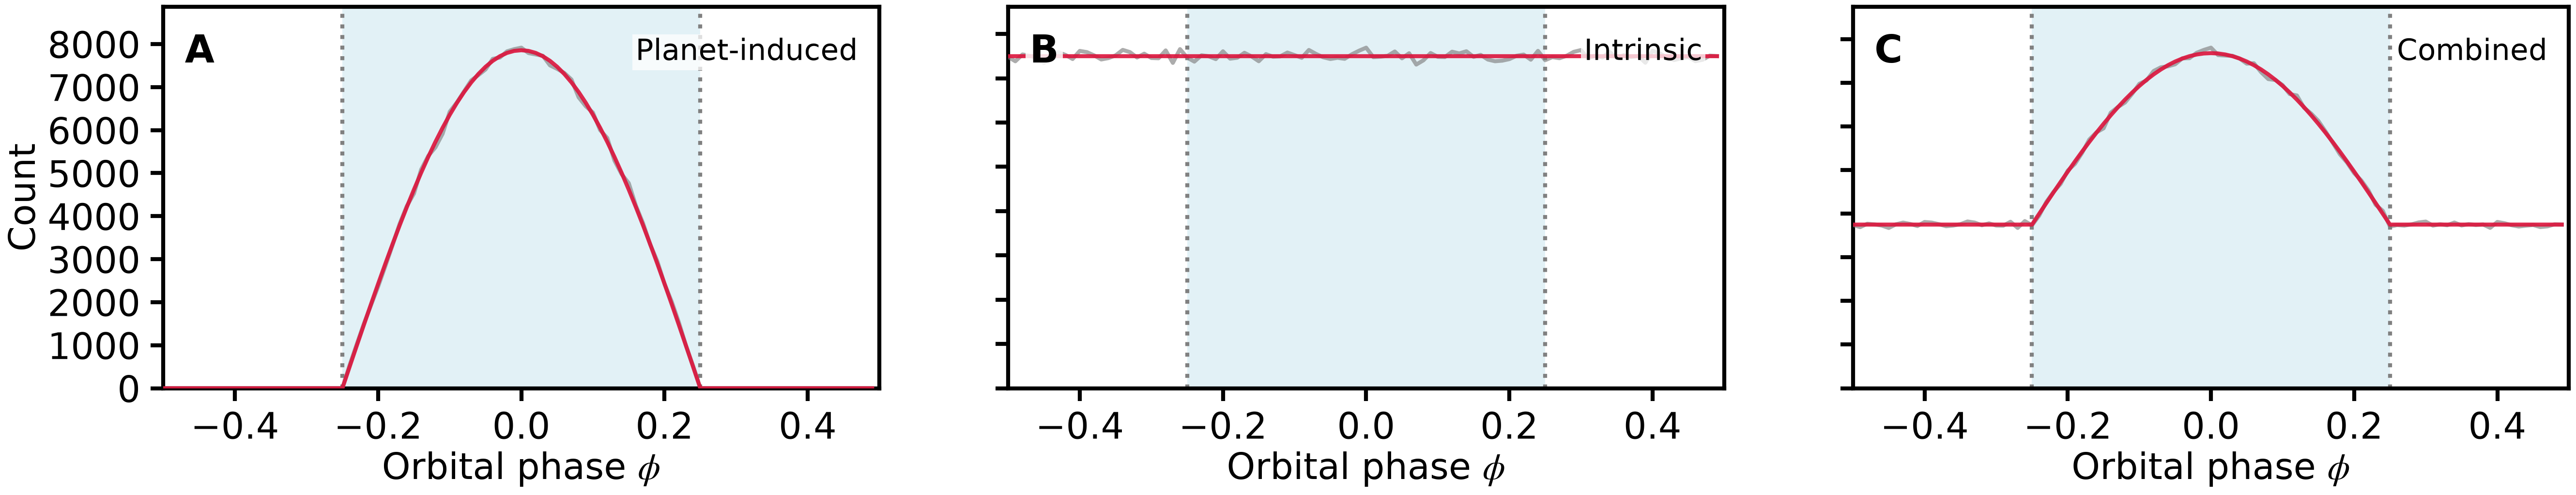

In [30]:
counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
    intrinsic_flaring_rate,
    planet_ratio,
    amount_of_flares,
    slope,
    E_thres,
    e_min,
    e_max,
    plot=True
)


## Sanity check: does the model recover the requested PIP?

This is the main check that was missing before.  
Because the SPI region covers half of the phase space, the expected planet-induced percentage is

\[
\mathrm{PIP} = P_{\rm in} - P_{\rm out}.
\]

For the corrected model, this should reproduce the input PIP.


In [31]:
ratios = [0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]

rows = []
for ratio in ratios:
    model = flare_distribution_model(
        intrinsic_flaring_rate=intrinsic_flaring_rate,
        planet_ratio=ratio,
        slope=slope,
        n_bins=100
    )

    recovered_pip, p_in, p_out = estimate_pip_from_distribution(
        model["p_total"],
        model["phase"]
    )

    rows.append({
        "Input PIP": ratio,
        "P_in": p_in,
        "P_out": p_out,
        "Recovered PIP = P_in - P_out": recovered_pip,
    })

sanity_df = pd.DataFrame(rows)
sanity_df


,Input PIP,P_in,P_out,Recovered PIP = P_in - P_out
0,0.00,0.500,0.500,0.00
1,0.05,0.525,0.475,0.05
2,0.25,0.625,0.375,0.25
3,0.50,0.750,0.250,0.50
4,0.75,0.875,0.125,0.75
5,0.95,0.975,0.025,0.95
6,1.00,1.000,0.000,1.00


## Comparing several PIP values

The curves below use the same plot style as the original notebook.  
The important correction is that they are normalised by a **single global maximum**, not by their own maximum. Otherwise a low-PIP model is forced to peak at 1 and can look much stronger than it actually is.


In [32]:
p = []
m = []
n = []

ratios = [0.05, 0.25, 0.50, 0.75, 0.95]

for ratio in ratios:
    counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
        0.5,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        plot=False
    )

    p.append(normalized_final_fit)
    m.append(counts)
    n.append(final_fit)


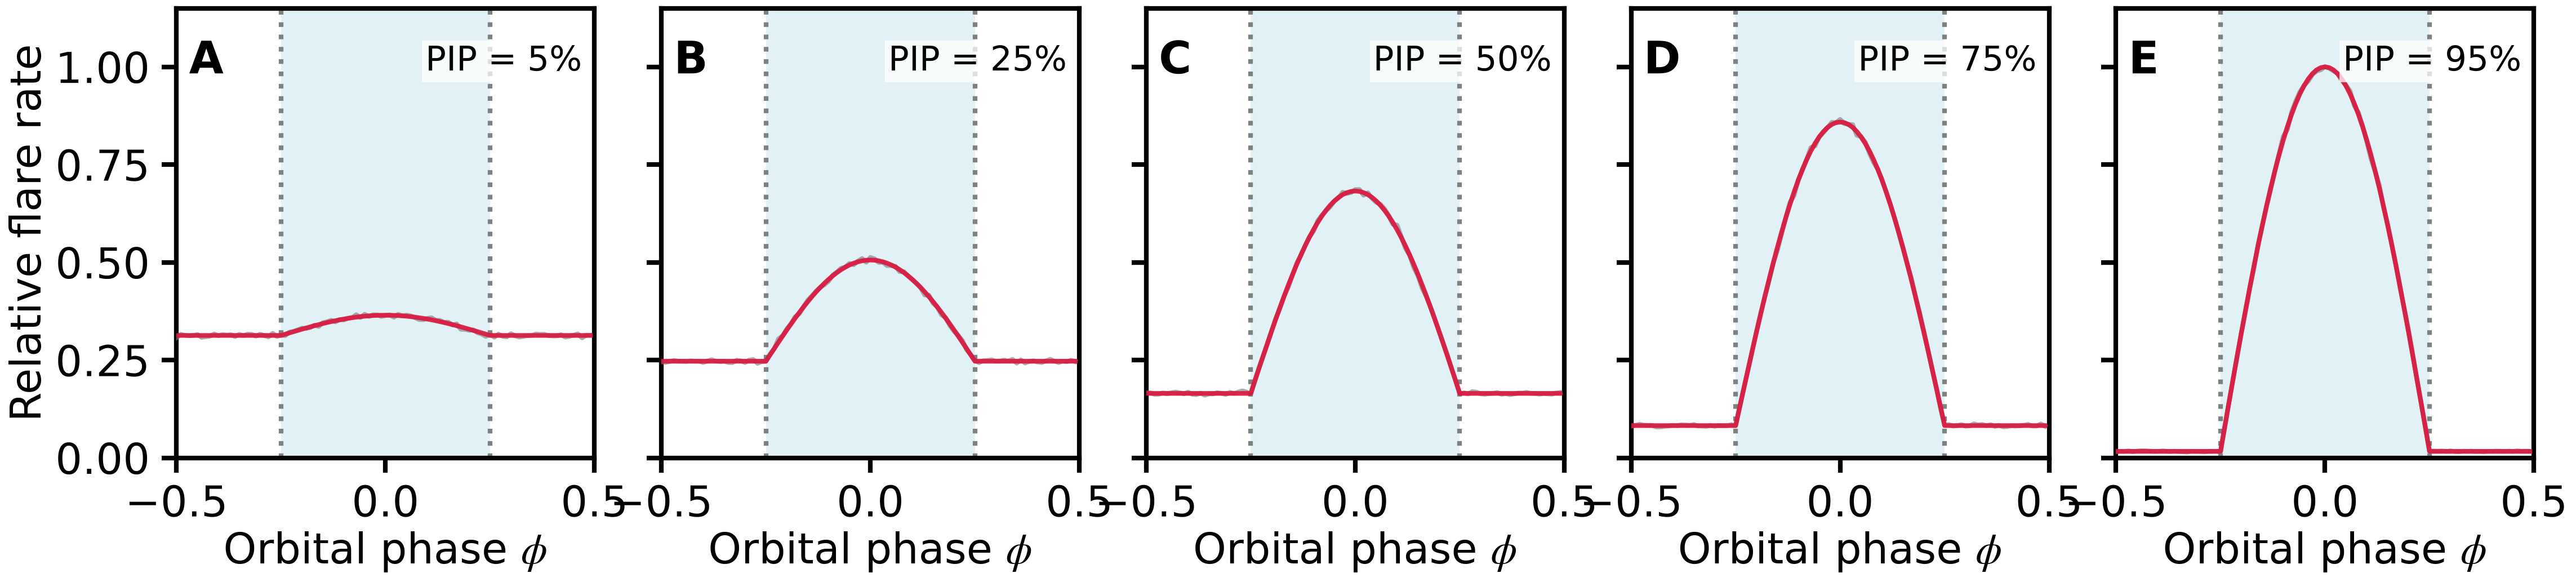

In [33]:
rows, cols = 1, 5

fig, axes = plt.subplots(rows, cols, figsize=(30, 7), sharey=True)
axes = np.atleast_1d(axes).flatten()

x = np.arange(-0.5, 0.5, 1 / 100)

# Use a global maximum so the relative amplitude between PIP values is preserved.
global_max = max(np.max(curve) for curve in n)

for i, ax_i in enumerate(axes):
    m_norm = m[i] / global_max
    n_norm = n[i] / global_max

    add_spi_region(ax_i, spi_width=0.25)

    ax_i.plot(
        x,
        m_norm,
        color=RAW_COLOR,
        alpha=0.65,
        lw=LINEWIDTH,
        label="Simulated data",
        zorder=5,
    )
    ax_i.plot(
        x,
        n_norm,
        color=MODEL_COLOR,
        alpha=0.9,
        lw=LINEWIDTH,
        label="Model",
        zorder=10,
    )

    ax_i.set_xlim(-0.5, 0.5)
    ax_i.set_ylim(0, 1.15)
    ax_i.set_xlabel(r"Orbital phase $\phi$")
    add_panel_label(ax_i, chr(ord("A") + i))
    add_inner_label(ax_i, rf"PIP = {ratios[i] * 100:.0f}%")
    apply_thesis_axis_style(ax_i)

    if i == 0:
        ax_i.set_ylabel("Relative flare rate")
    else:
        ax_i.tick_params(axis="y", labelleft=False)

fig.subplots_adjust(left=0.06, right=0.99, bottom=0.20, top=0.96, wspace=0.16)
plt.show()


## Single plot with the fitted models only

This version makes it easier to see the progression with PIP.  
The colour bar is fixed from 0 to 100%, so it always mentions both the minimum and maximum possible PIP values.


## Single plot with the fitted models only

The thesis-style version of this figure is generated in the next cell.

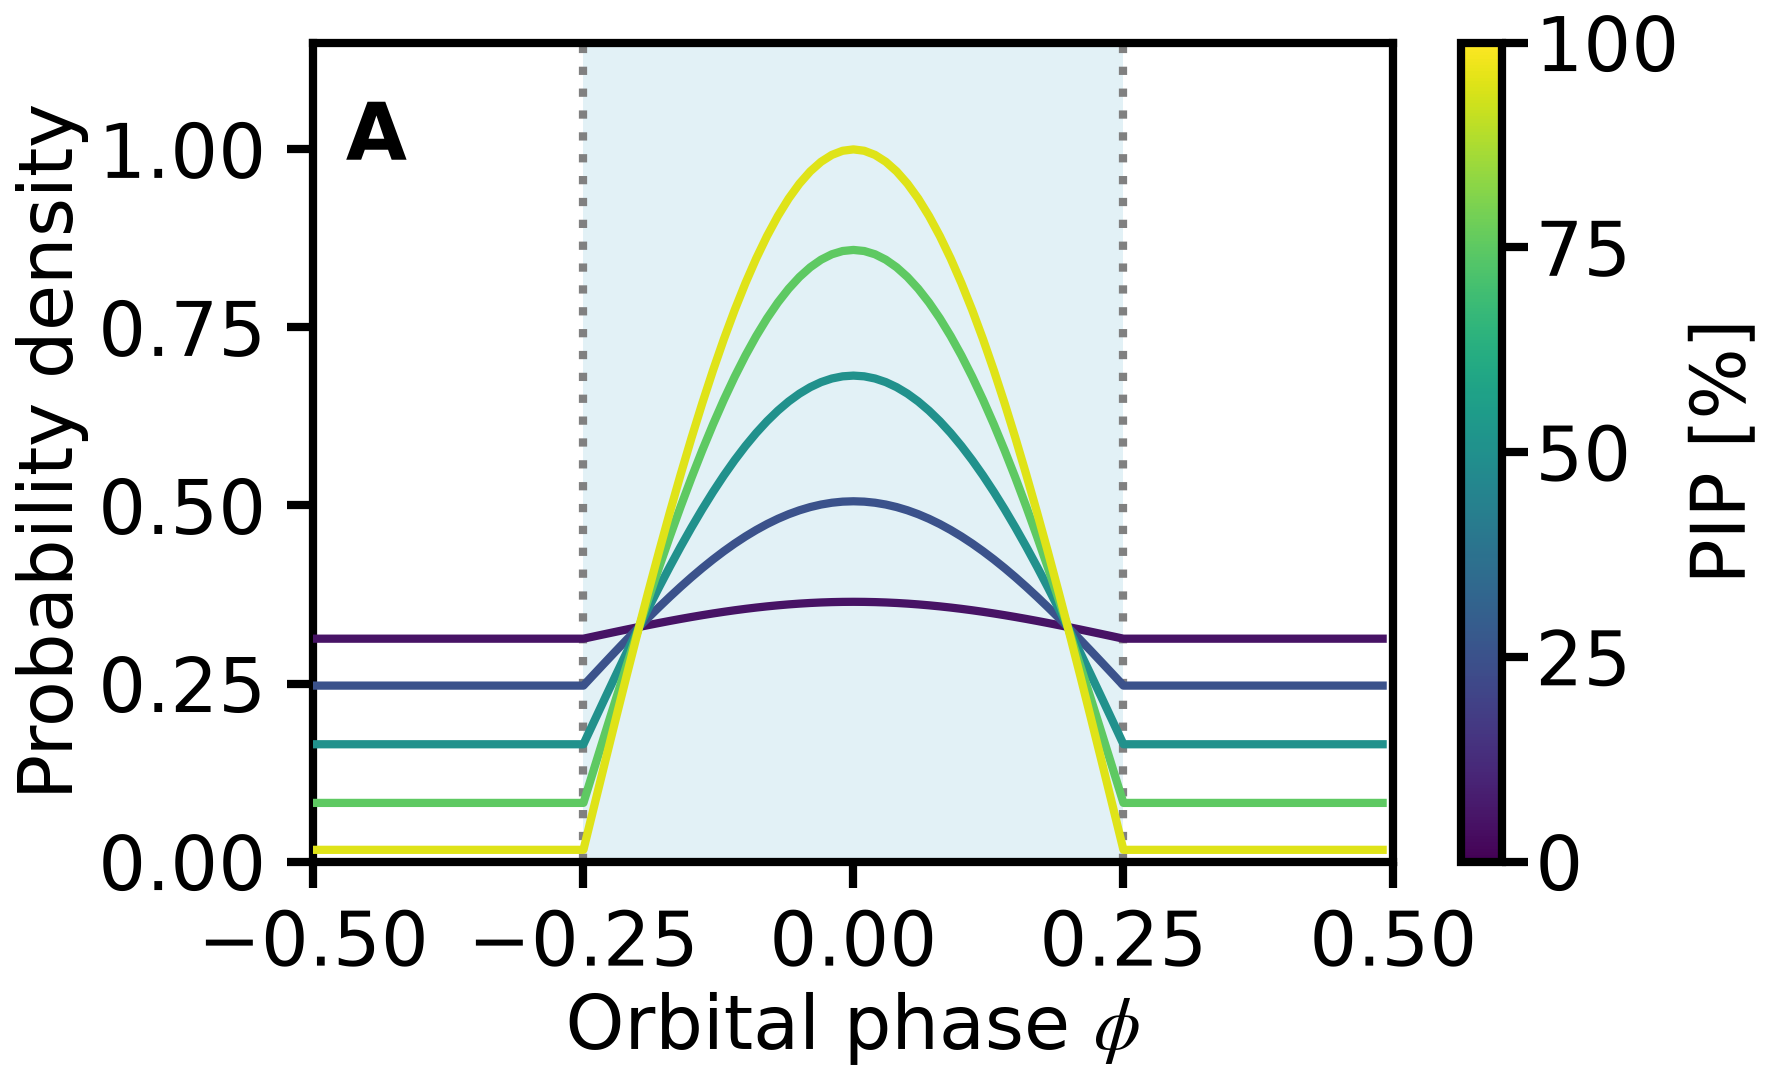

In [34]:
# ------------------------------------------------------------
# Single-panel fitted-model figure with PIP encoded by color
# ------------------------------------------------------------
x = np.arange(-0.5, 0.5, 1 / 100)

pip_percent = np.array(ratios) * 100
norm = Normalize(vmin=0, vmax=100)
cmap = plt.cm.viridis

global_max = max(np.max(curve) for curve in n)

fig, ax = plt.subplots(figsize=(12, 7))

add_spi_region(ax, spi_width=0.25)

for i in range(len(p)):
    n_norm = n[i] / global_max
    ax.plot(
        x,
        n_norm,
        color=cmap(norm(pip_percent[i])),
        linewidth=LINEWIDTH,
        zorder=10,
    )

# Colorbar is scientifically necessary because color encodes PIP.
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PIP [%]")
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.ax.tick_params(width=LINEWIDTH, length=7 * SCALE)
cbar.outline.set_linewidth(LINEWIDTH)

ax.set_xlabel(r"Orbital phase $\phi$")
ax.set_ylabel("Probability density")
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(0, 1.15)

add_panel_label(ax, "A")
apply_thesis_axis_style(ax)

fig.subplots_adjust(left=0.13, right=0.88, bottom=0.18, top=0.96)
plt.show()


## Waiting-time plots

This keeps the same kind of waiting-time plot as the original notebook, but now the fake flare times are drawn from the corrected phase distribution.


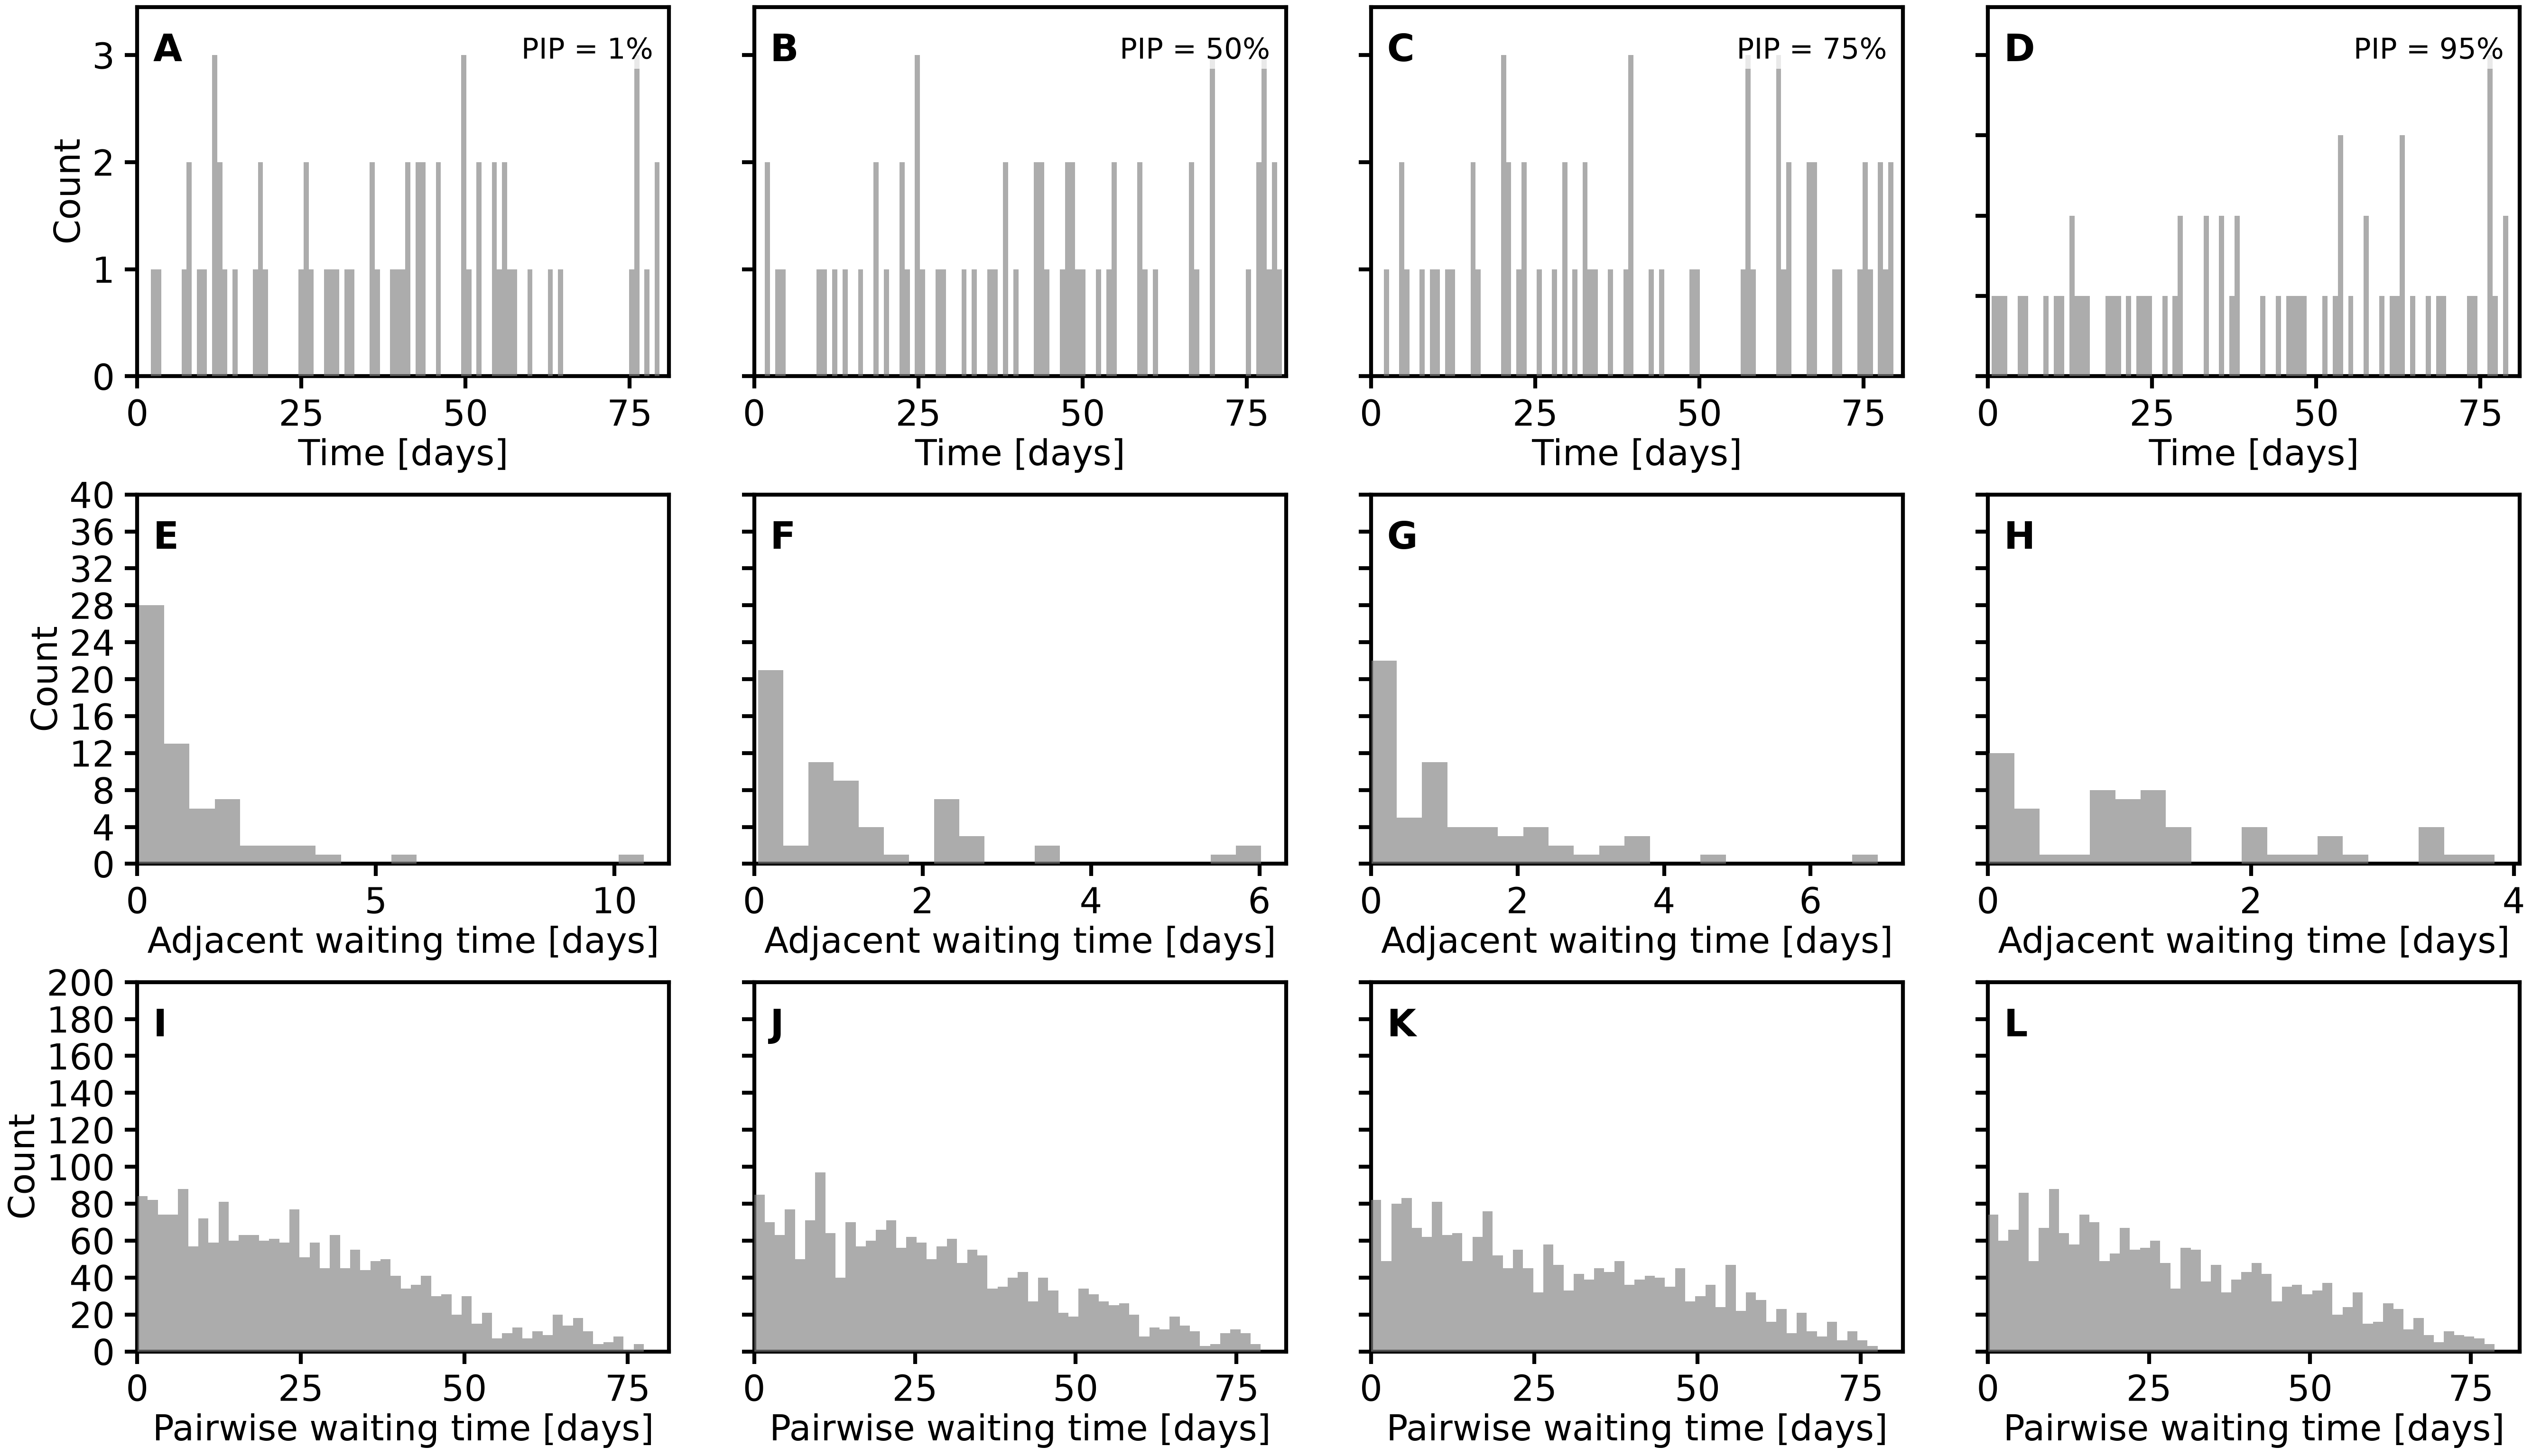

In [35]:
slope = -2
amount_of_flares = int(1e6)
intrinsic_flaring_rate = 0.8
planet_ratio_list = [0.01, 0.50, 0.75, 0.95]
total_observing_time = 81  # days
Period = 1.208             # days

fig, axes = plt.subplots(3, 4, figsize=(36, 21))

for i, ratio in enumerate(planet_ratio_list):
    flare_times = Fake_data(
        intrinsic_flaring_rate,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        total_observing_time,
        Period,
        plot=False,
    )

    diff = np.diff(np.sort(flare_times))
    diff2 = pairwise_waiting_times(np.sort(flare_times))

    plot_specs = [
        (flare_times, 100, "Time [days]", (0, total_observing_time), None),
        (diff, 20, r"Adjacent waiting time [days]", (0, None), 40),
        (diff2, 50, r"Pairwise waiting time [days]", (0, None), 200),
    ]

    for row_idx, (data, bins, xlabel, xlim, ylim_top) in enumerate(plot_specs):
        ax_i = axes[row_idx, i]
        counts_hist, _, _ = ax_i.hist(
            data,
            bins=bins,
            color=RAW_COLOR,
            alpha=0.65,
            linewidth=0,
            zorder=5,
        )
        ax_i.set_xlabel(xlabel)
        ax_i.set_xlim(left=xlim[0], right=xlim[1])
        if ylim_top is not None:
            ax_i.set_ylim(0, ylim_top)
        elif len(counts_hist) > 0 and np.nanmax(counts_hist) > 0:
            ax_i.set_ylim(0, 1.15 * np.nanmax(counts_hist))

        if i == 0:
            ax_i.set_ylabel("Count")
        else:
            ax_i.tick_params(axis="y", labelleft=False)

        add_panel_label(ax_i, chr(ord("A") + row_idx * len(planet_ratio_list) + i))
        apply_thesis_axis_style(ax_i, integer_y=True)

    add_inner_label(axes[0, i], rf"PIP = {ratio * 100:.0f}%")

fig.subplots_adjust(left=0.06, right=0.99, bottom=0.08, top=0.98, wspace=0.16, hspace=0.32)
plt.show()


## Picking flares from the corrected model

This keeps the same type of sampling plot as the original notebook.


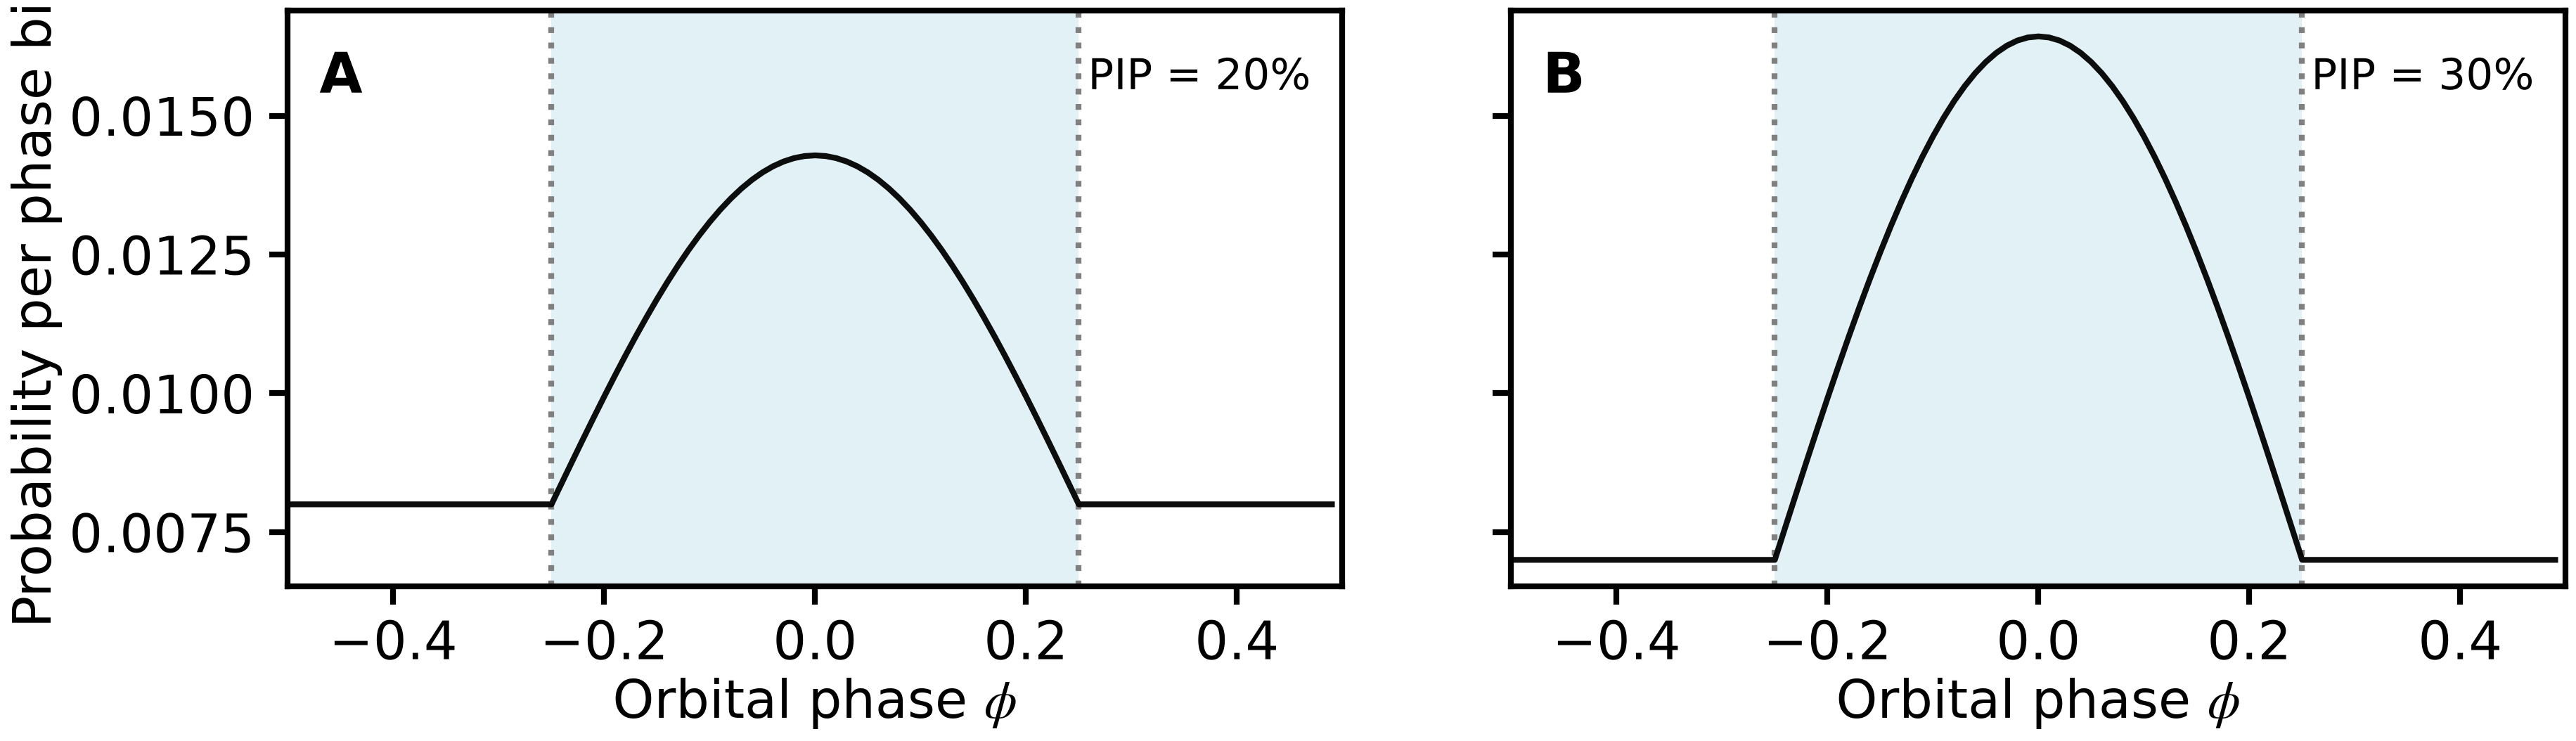

In [36]:
planet_induced_ratios = [0.20, 0.30]
amount_of_flares = int(1e6)
T_baseline = 500
intrinsic_flare_rate = 0.2
slope = -2
E_thres = 2
e_min = 0.1
e_max = 1e8

fig, axes = plt.subplots(1, 2, figsize=(24, 7), sharey=True)

x = np.arange(-0.5, 0.5, 1 / 100)

for i, ratio in enumerate(planet_induced_ratios):
    counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
        intrinsic_flare_rate,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        plot=False,
    )

    ax_i = axes[i]
    add_spi_region(ax_i, spi_width=0.25)
    ax_i.plot(
        x,
        final_fit / final_fit.sum(),
        color=PRIMARY_COLOR,
        alpha=0.95,
        lw=LINEWIDTH,
        zorder=10,
    )

    ax_i.set_xlim(-0.5, 0.5)
    ax_i.set_xlabel(r"Orbital phase $\phi$")
    if i == 0:
        ax_i.set_ylabel("Probability per phase bin")
    else:
        ax_i.tick_params(axis="y", labelleft=False)

    add_panel_label(ax_i, chr(ord("A") + i))
    add_inner_label(ax_i, rf"PIP = {ratio * 100:.0f}%")
    apply_thesis_axis_style(ax_i)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.96, wspace=0.16)
save_thesis_figure(fig, "PDF_for_various_PIP_corrected.pdf")
plt.show()


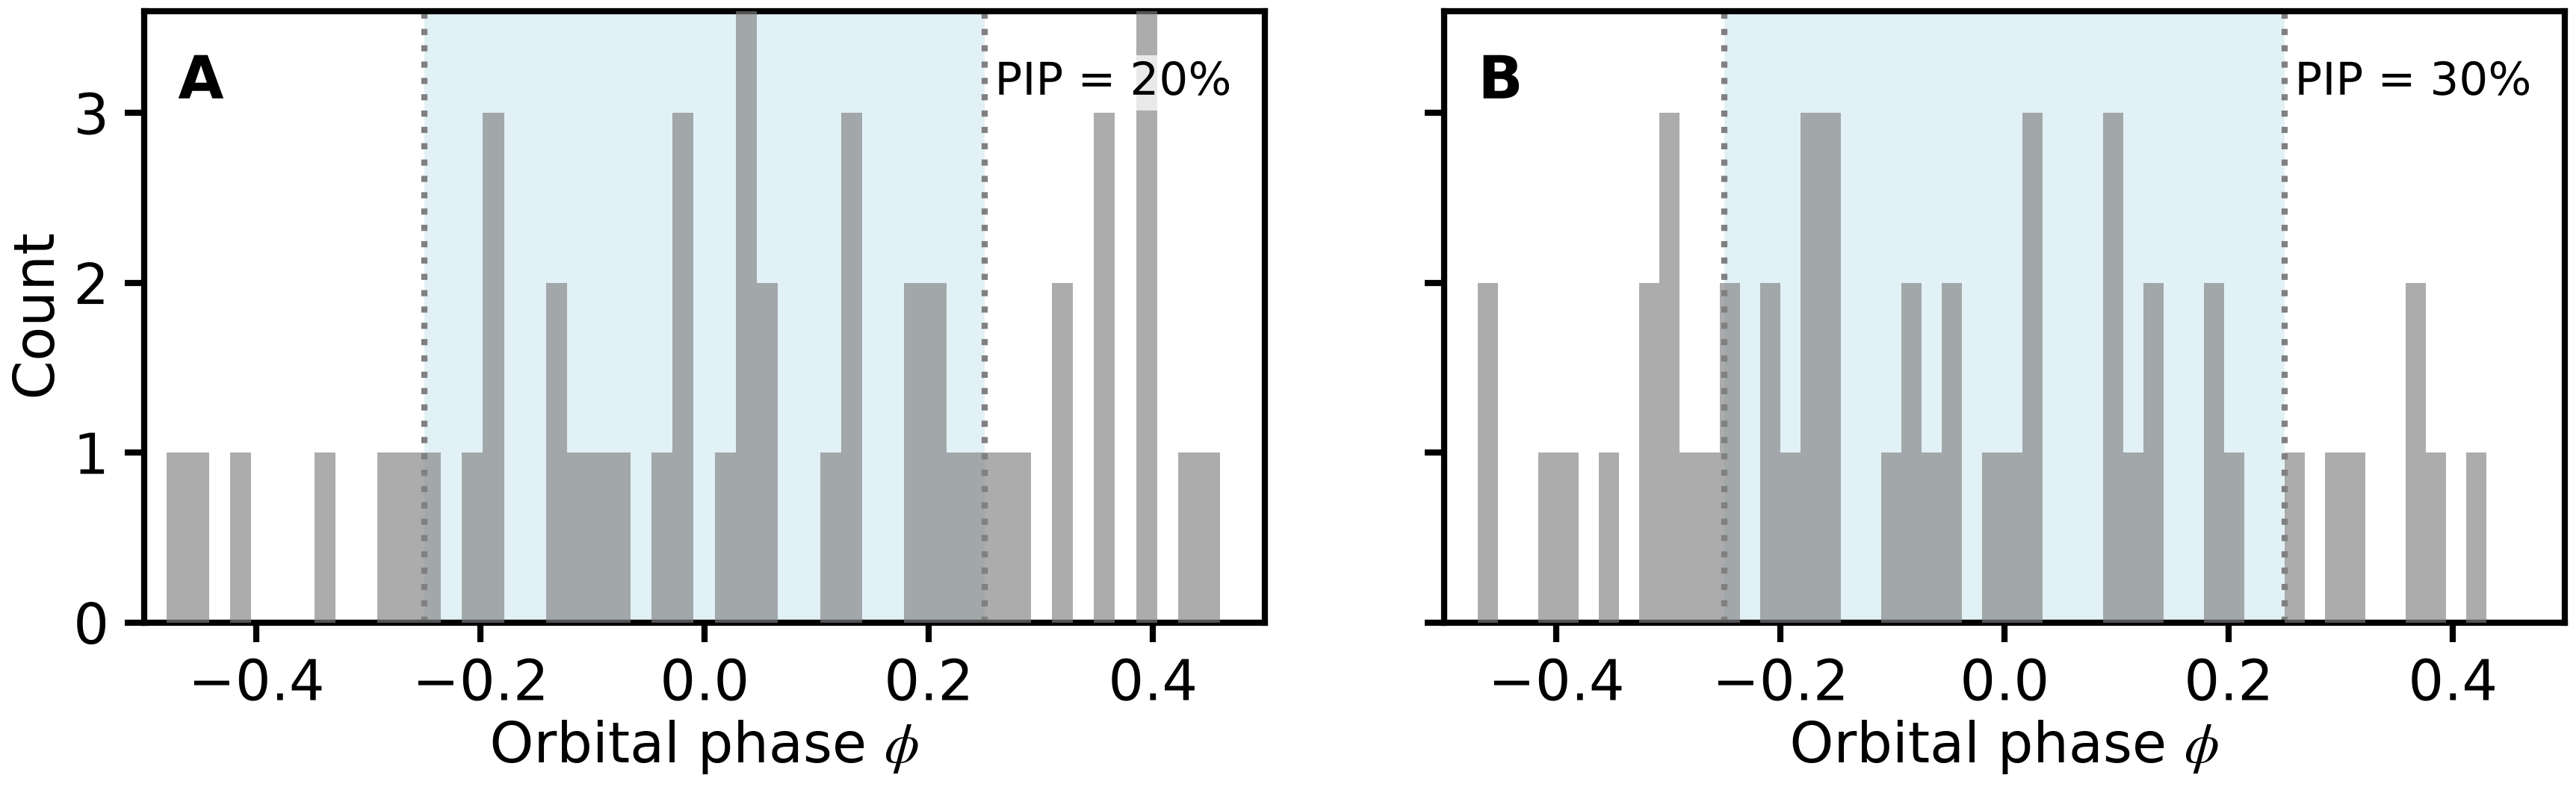

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(24, 7), sharey=True)

for i, ratio in enumerate(planet_induced_ratios):
    counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
        intrinsic_flare_rate,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        plot=False,
    )

    points = sample_points(x, normalized_final_fit, 50)

    ax_i = axes[i]
    add_spi_region(ax_i, spi_width=0.25)
    counts_hist, _, _ = ax_i.hist(
        points,
        bins=50,
        color=RAW_COLOR,
        alpha=0.65,
        linewidth=0,
        zorder=5,
    )

    ax_i.set_xlim(-0.5, 0.5)
    ax_i.set_xlabel(r"Orbital phase $\phi$")
    if i == 0:
        ax_i.set_ylabel("Count")
    else:
        ax_i.tick_params(axis="y", labelleft=False)
    if len(counts_hist) > 0 and np.nanmax(counts_hist) > 0:
        ax_i.set_ylim(0, 1.20 * np.nanmax(counts_hist))

    add_panel_label(ax_i, chr(ord("A") + i))
    add_inner_label(ax_i, rf"PIP = {ratio * 100:.0f}%")
    apply_thesis_axis_style(ax_i, integer_y=True)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.96, wspace=0.16)
plt.show()


## Final simple histogram check

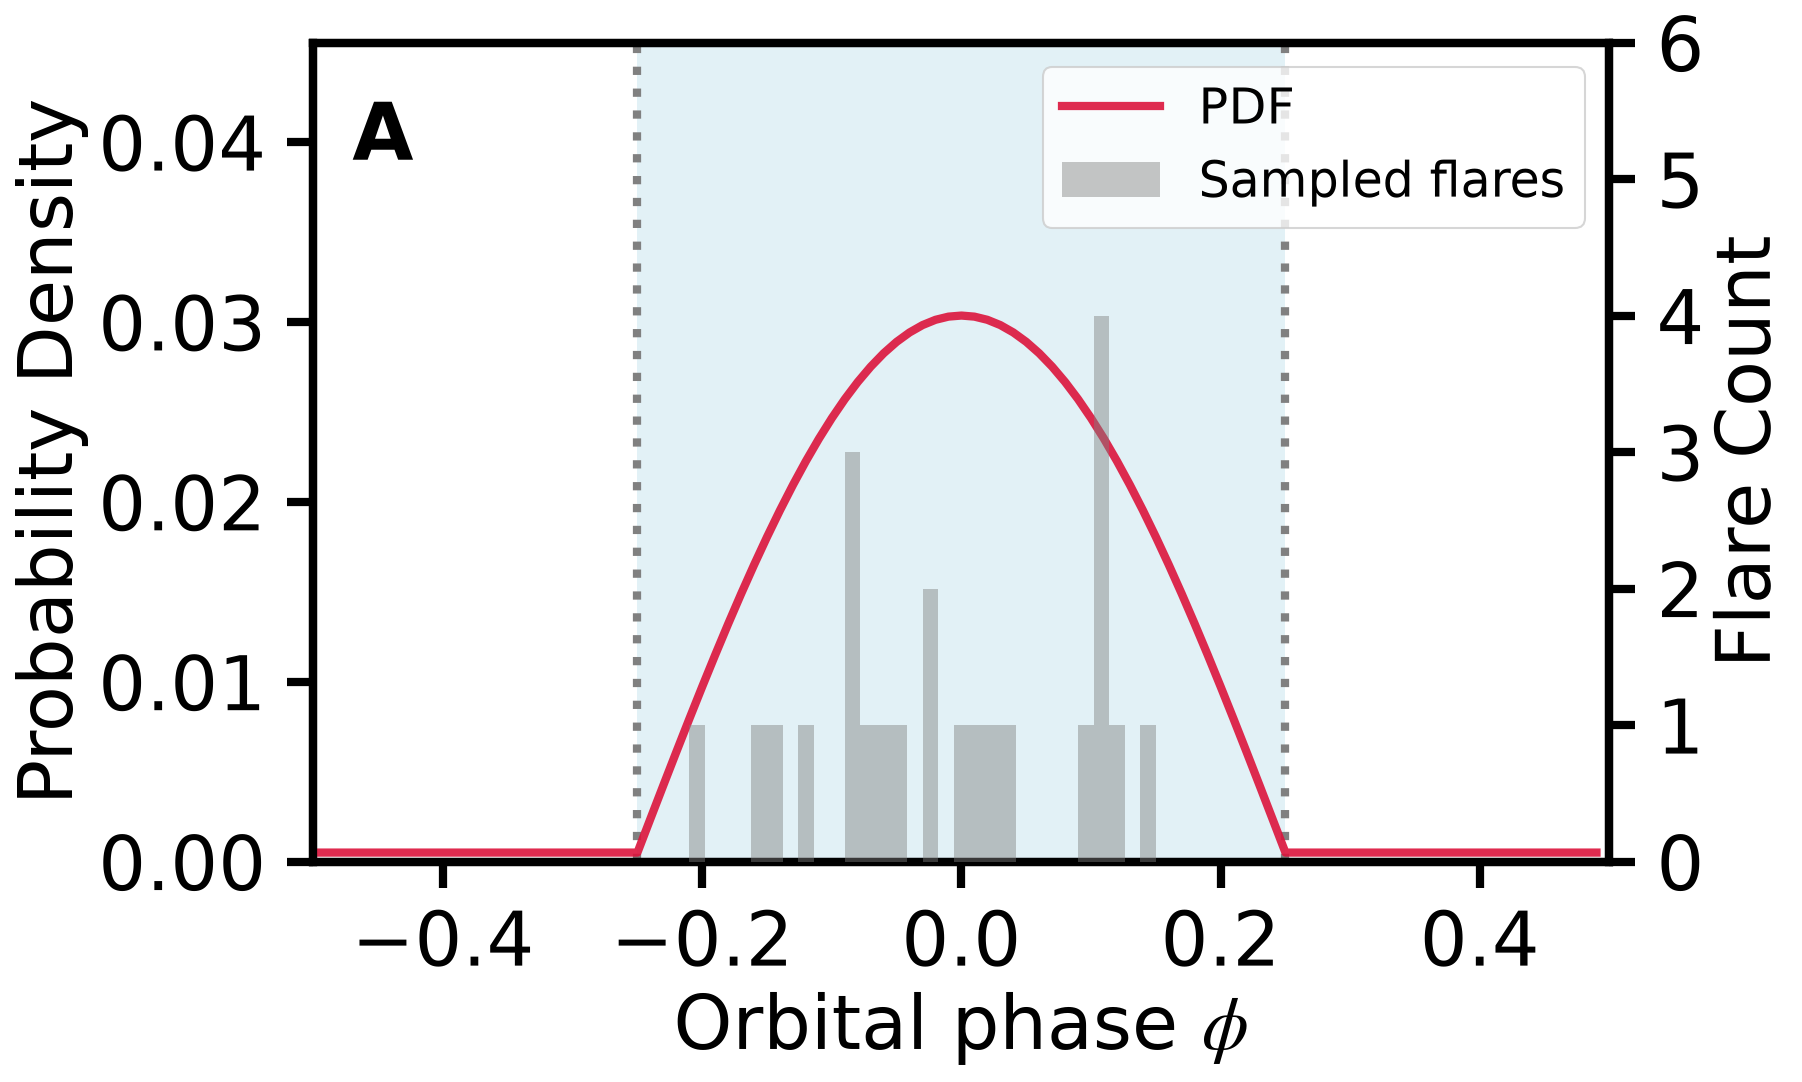

In [38]:
# Simple check for one model.
counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
    0.24,
    0.95,
    int(1e6),
    slope,
    E_thres,
    e_min,
    e_max,
    plot=False,
)

points = sample_points(x, normalized_final_fit, 23)

fig, ax1 = plt.subplots(figsize=(12, 7))

model_line, = ax1.plot(
    x,
    normalized_final_fit,
    color=MODEL_COLOR,
    alpha=0.9,
    lw=LINEWIDTH,
    label="PDF",
    zorder=10,
)
ax1.set_ylabel("Probability Density")
ax1.set_xlabel(r"Orbital phase $\phi$")
ax1.set_xlim(-0.5, 0.5)
ax1.set_ylim(0, 1.5 * np.nanmax(normalized_final_fit))
add_spi_region(ax1, spi_width=0.25)
add_panel_label(ax1, "A")
apply_thesis_axis_style(ax1)

ax2 = ax1.twinx()
counts_hist, _, patches = ax2.hist(
    points,
    bins=30,
    color=RAW_COLOR,
    alpha=0.45,
    linewidth=0,
    label="Sampled flares",
    zorder=5,
)
ax2.set_ylabel("Flare Count")
if len(counts_hist) > 0 and np.nanmax(counts_hist) > 0:
    ax2.set_ylim(0, 1.5 * np.nanmax(counts_hist))
apply_thesis_axis_style(ax2, integer_y=True, scalar_x=False)

ax1.legend(
    handles=[model_line, patches[0]],
    labels=["PDF", "Sampled flares"],
    loc="upper right",
    frameon=True,
    fontsize=FONTSIZE * 0.65,
)

fig.subplots_adjust(left=0.14, right=0.86, bottom=0.18, top=0.96)
plt.show()


## Optional export cells

The original notebook contained several long export loops.  
I kept them commented out here, because they can create many files and take a long time to run.


In [ ]:
# pir = 0.999
# periods = np.arange(0.5,8.1,0.01)
# T_baseline = 100
# n_flares = 10
# ifr = n_flares / T_baseline

# for random_period in periods:
#     flare_times = Fake_data_RT(
#         ifr,
#         pir,
#         amount_of_flares,
#         slope,
#         E_thres,
#         e_min,
#         e_max,
#         T_baseline,
#         random_period,
#         plot=False
#     )
    
#     out_dir = f"../Data/Harmonic-test/50percent"
#     os.makedirs(out_dir, exist_ok=True)
    
#     df = pd.DataFrame({"tstart": flare_times})
#     df["true_period"] = round(random_period,1)
#     df["T_baseline"] = T_baseline
#     df["planet_induced_ratio"] = pir
    
#     df.to_csv(f"{out_dir}/{random_period:.2f}_flares.csv", index=False)
